In [1]:
import torch
from torch import nn
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt

In [2]:
# make data set
samples = 1000
classes = 4
features = 2
manual_seed = 42

X, y = make_blobs(n_samples=samples, centers=classes, n_features=features, random_state=manual_seed, cluster_std=1.5)

In [3]:
# make tensors from numpy
X_blob = torch.from_numpy(X).type(torch.float)
y_blob = torch.from_numpy(y).type(torch.float)

In [4]:
# split into train test
from sklearn.model_selection import train_test_split

In [5]:
x_train_blob, x_test_blob, y_train_blob, y_test_blob = train_test_split(X_blob, y_blob, test_size=0.2, random_state=42)
x_train_blob.size(), x_test_blob.size(), y_train_blob.size(), y_test_blob.size() 

(torch.Size([800, 2]),
 torch.Size([200, 2]),
 torch.Size([800]),
 torch.Size([200]))

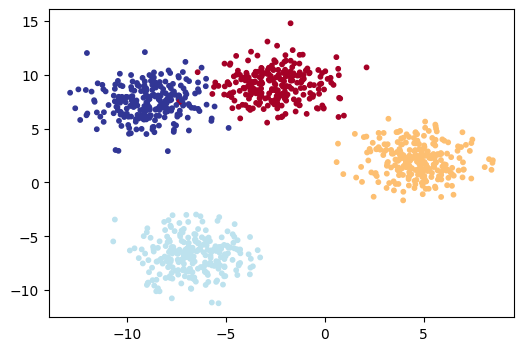

In [6]:
# visualise
plt.figure(figsize=(6,4))
plt.scatter(X_blob[:,0], X_blob[:,1], s=10, c=y_blob , cmap=plt.cm.RdYlBu)

# we will be needing non linear functions to fit models in this dataset

In [7]:
# define model
class BlobModel_0(nn.Module):
    def __init__(self, input_features:int, output_features:int, neurons:int=8):
        """ A multi-class classification model initializer class.

        Args: 
            in_features (int): input features of the model.
            out_features (int): no of output classes of the model.
            hiden_layers (int): no of hidden layers, default 8.

        Return:

        Example: 
        """
        super().__init__()
        self.linear_layer_stack = nn.Sequential(
            nn.Linear(in_features=input_features, out_features=neurons),
            nn.ReLU(),
            nn.Linear(in_features=neurons, out_features=neurons),
            nn.ReLU(),
            nn.Linear(in_features=neurons, out_features=output_features)
        )

    def forward(self, X):
        return self.linear_layer_stack(X)
        

In [8]:
model_0 = BlobModel_0(input_features=2, output_features=4, neurons=10)

In [9]:
model_0

BlobModel_0(
  (linear_layer_stack): Sequential(
    (0): Linear(in_features=2, out_features=10, bias=True)
    (1): ReLU()
    (2): Linear(in_features=10, out_features=10, bias=True)
    (3): ReLU()
    (4): Linear(in_features=10, out_features=4, bias=True)
  )
)

In [10]:
model_0.state_dict()

OrderedDict([('linear_layer_stack.0.weight',
              tensor([[-0.3553,  0.0309],
                      [-0.6305, -0.4275],
                      [ 0.2964,  0.2675],
                      [ 0.1455,  0.6143],
                      [-0.3869,  0.5901],
                      [ 0.1833,  0.5931],
                      [-0.6499,  0.6527],
                      [-0.6393,  0.0027],
                      [-0.1400,  0.5177],
                      [-0.6375, -0.1580]])),
             ('linear_layer_stack.0.bias',
              tensor([ 0.2070, -0.3982, -0.2527, -0.5391,  0.2145,  0.3291, -0.0074,  0.2361,
                       0.0373, -0.3090])),
             ('linear_layer_stack.2.weight',
              tensor([[ 0.1452,  0.0169, -0.2017, -0.2122, -0.1881,  0.2512,  0.2898, -0.1440,
                       -0.0403,  0.0275],
                      [-0.1629,  0.1060,  0.1342, -0.2087,  0.1715,  0.2513,  0.0709, -0.0603,
                        0.1277,  0.2195],
                      [ 0.2938, -

In [11]:
# predictions by untrained models
model_0.eval()
with torch.inference_mode():
    y_logits_untrained = model_0(x_test_blob)

y_probs_untrained = torch.softmax(y_logits_untrained, dim=1)
print(y_logits_untrained[:5])

y_output_untrained = torch.argmax(y_probs_untrained)
print(y_probs_untrained[:5])

print(f'I/p: {y_probs_untrained[10]} O/P: {torch.argmax(y_probs_untrained[10])} with probability of {y_probs_untrained[10][torch.argmax(y_probs_untrained[10])]}') 

tensor([[ 0.1617,  0.9165,  0.3167,  0.2928],
        [-0.1766,  2.0321,  0.7047,  1.2520],
        [-0.5073,  0.8651, -0.3323,  0.0473],
        [ 0.0127,  0.3315,  0.0882, -0.0586],
        [ 0.3510,  2.1926,  0.9178,  0.9585]])
tensor([[0.1840, 0.3914, 0.2149, 0.2098],
        [0.0599, 0.5454, 0.1446, 0.2500],
        [0.1269, 0.5008, 0.1512, 0.2211],
        [0.2280, 0.3137, 0.2459, 0.2124],
        [0.0917, 0.5783, 0.1616, 0.1684]])
I/p: tensor([0.0959, 0.5204, 0.1712, 0.2124]) O/P: 1 with probability of 0.5204155445098877


In [12]:
y_pred_untrained = torch.argmax(y_probs_untrained, dim=1)
y_pred_untrained

tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1])

In [13]:
# make loss function and optimizer
loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_0.parameters(), lr=0.1)

In [14]:
# setup evaluation matrix
def accurcy_fn(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item()
    acc = (correct/len(y_pred)) * 100
    return acc

In [15]:
# Plot linear data or training and test and predictions (optional)
import numpy as np
def plot_predictions(
    train_data, train_labels, test_data, test_labels, predictions=None
):
    """
  Plots linear training data and test data and compares predictions.
  """
    plt.figure(figsize=(10, 7))

    # Plot training data in blue
    plt.scatter(train_data, train_labels, c="b", s=4, label="Training data")

    # Plot test data in green
    plt.scatter(test_data, test_labels, c="g", s=4, label="Testing data")

    if predictions is not None:
        # Plot the predictions in red (predictions were made on the test data)
        plt.scatter(test_data, predictions, c="r", s=4, label="Predictions")

    # Show the legend
    plt.legend(prop={"size": 14})

def plot_decision_boundary(model: torch.nn.Module, X: torch.Tensor, y: torch.Tensor):
    """Plots decision boundaries of model predicting on X in comparison to y.

    Source - https://madewithml.com/courses/foundations/neural-networks/ (with modifications)
    """
    # Put everything to CPU (works better with NumPy + Matplotlib)
    model.to("cpu")
    X, y = X.to("cpu"), y.to("cpu")

    # Setup prediction boundaries and grid
    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 101), np.linspace(y_min, y_max, 101))

    # Make features
    X_to_pred_on = torch.from_numpy(np.column_stack((xx.ravel(), yy.ravel()))).float()

    # Make predictions
    model.eval()
    with torch.inference_mode():
        y_logits = model(X_to_pred_on)

    # Test for multi-class or binary and adjust logits to prediction labels
    if len(torch.unique(y)) > 2:
        y_pred = torch.softmax(y_logits, dim=1).argmax(dim=1)  # mutli-class
    else:
        y_pred = torch.round(torch.sigmoid(y_logits))  # binary

    # Reshape preds and plot
    y_pred = y_pred.reshape(xx.shape).detach().numpy()
    plt.contourf(xx, yy, y_pred, cmap=plt.cm.RdYlBu, alpha=0.7)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=10, cmap=plt.cm.RdYlBu)
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())

In [16]:
x_train_blob[:1], y_train_blob[:1]

(tensor([[5.0405, 3.3076]]), tensor([1.]))

In [17]:
x_test_blob[:1], y_test_blob[:1]

(tensor([[4.6675, 4.4878]]), tensor([1.]))

In [18]:
epoch_list = []
train_loss_list = []
test_loss_list = []

torch.manual_seed(42)
epochs = 1000
for epoch in range(epochs):
    epoch_list.append(epoch)
    
    #-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-TRAINING LOOP#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#
    
    # 1. TRAINING | PUT MODEL IN TRAINING MODE
    model_0.train()

    # 2. FORWARD PASS
    y_logits_trained = model_0(x_train_blob)
    # y_preds_trained = torch.softmax(y_logits_trained, dim=1).argmax(dim=1)

    # 3. LOSS CALCULATIONS | training loss
    train_loss = loss_fn(y_logits_trained, y_train_blob.type(torch.LongTensor))
    # 3a. CALCULATE ACCURACY HERE
    train_acc = accurcy_fn(y_true=y_train_blob, y_pred=torch.softmax(y_logits_trained, dim=1).argmax(dim=1))
    train_loss_list.append(train_loss.item())
        
    # 4. zero the optimizer's tensors
    optimizer.zero_grad()

    # 5. calculate the slopes/ gradients | back propagation
    train_loss.backward()
                     
    # 6. optimizer will calculate the changes | optimizer step
    optimizer.step()
        
    #-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-TESTING LOOP#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#
    
    # 1. TESTING | PUT MODEL IN EVAL MODE
    model_0.eval()
    with torch.inference_mode():
        
    # 2. FORWARD PASS
        y_pred_test_logits = model_0(x_test_blob)
        # y_preds_test = torch.softmax(y_pred_test_logits, dim=1).argmax(dim=1)

    # 3. LOSS CALCULATIONS | testing loss
        test_loss = loss_fn(y_pred_test_logits, y_test_blob.type(torch.LongTensor))
        test_acc = accurcy_fn(y_pred=torch.softmax(y_pred_test_logits, dim=1).argmax(dim=1), y_true=y_test_blob)
        test_loss_list.append(test_loss.item())

    #-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-PRINT OUT LOOP#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#-#    
        
    if epoch % 10 == 0 :
        print(f'Epoch: {epoch} | Training_Loss: {train_loss:.3f} | Training_Acc:{train_acc:.3f}% | Test_Loss: {test_loss:.3f} | Test_Acc: {test_acc:.3f}%')



/home/aj/miniconda3/envs/genai/lib/python3.10/site-packages/torch/autograd/graph.py:841: UserWarning: CUDA initialization: CUDA unknown error - this may be due to an incorrectly set up environment, e.g. changing env variable CUDA_VISIBLE_DEVICES after program start. Setting the available devices to be zero. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Epoch: 0 | Training_Loss: 1.700 | Training_Acc:26.125% | Test_Loss: 1.081 | Test_Acc: 48.500%
Epoch: 10 | Training_Loss: 0.468 | Training_Acc:95.375% | Test_Loss: 0.397 | Test_Acc: 94.000%
Epoch: 20 | Training_Loss: 0.203 | Training_Acc:99.250% | Test_Loss: 0.159 | Test_Acc: 99.500%
Epoch: 30 | Training_Loss: 0.107 | Training_Acc:99.250% | Test_Loss: 0.085 | Test_Acc: 99.500%
Epoch: 40 | Training_Loss: 0.072 | Training_Acc:99.250% | Test_Loss: 0.056 | Test_Acc: 99.500%
Epoch: 50 | Training_Loss: 0.056 | Training_Acc:99.250% | Test_Loss: 0.043 | Test_Acc: 99.500%
Epoch: 60 | Training_Loss: 0.047 | Training_Acc:99.250% | Test_Loss: 0.036 | Test_Acc: 99.500%
Epoch: 70 | Training_Loss: 0.042 | Training_Acc:99.125% | Test_Loss: 0.031 | Test_Acc: 99.500%
Epoch: 80 | Training_Loss: 0.038 | Training_Acc:99.125% | Test_Loss: 0.028 | Test_Acc: 99.500%
Epoch: 90 | Training_Loss: 0.036 | Training_Acc:99.125% | Test_Loss: 0.026 | Test_Acc: 99.500%
Epoch: 100 | Training_Loss: 0.034 | Training_Acc:99

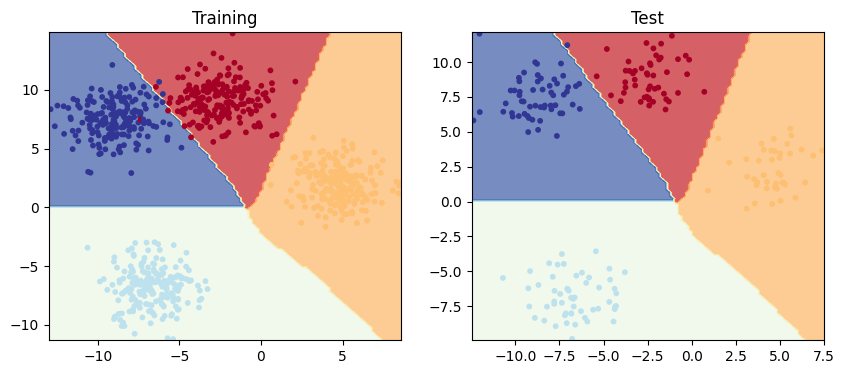

In [19]:
# observation: model is not learning anything
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.title('Training')
plot_decision_boundary(model_0, x_train_blob, y_train_blob)
plt.subplot(1,2,2)
plt.title('Test')
plot_decision_boundary(model_0, x_test_blob, y_test_blob)

# Q: Can this be achieved via linea model?
# A: Yes we only need straight lines to seperate the regions.

# more metrices
* precision
* recall
* f1 score
* confusion matrix
* classification report